# $\Psi(2S)$ discovery with CMS data
#### Gabriele Radano, Matteo Bellino - Spring semester 2025

# 0. Importing packages

In [1]:
# Importing packages
import pickle as pkl                 # Needed to import the pkl files
import numpy  as np
import math                          # Needed to check if the bNLL is NaN (negative number inside the logarithm)
import matplotlib.pyplot as plt
import lmfit                         # Package to minimize functions (it is more well-structured than scipy.optimize)
from dataclasses import dataclass
from scipy.integrate import quad     # Numerical integral evaluation, useful to compute the integral of the model inside the bin
import sys                           # Needed to know what's the highest float value accepted
from collections.abc import Iterable # Needed to check inside crystall_ball if we are giving an array or a float

# 1. Loading data

In [2]:
# Importing data from files
with open('DataSet.pkl', 'rb') as file: # The 'rb' stands for 'read binary', necessary for this kind of file
    data_HS = pkl.load(file)            # Data with High Statistics 
    
with open('DataSet_lowstat.pkl', 'rb') as file:
    data_LS = pkl.load(file)            # Data with Low Statistics

83


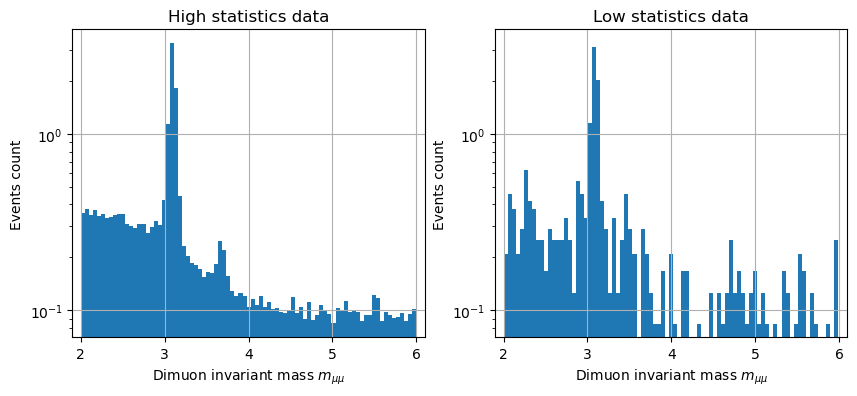

In [17]:
# Plotting raw data
normalize = True
scale     = 'log'
bin_num   = int(np.sqrt(len(data_HS))/2)
print(bin_num)
fig, axes = plt.subplots(1,2, figsize=(10,4))

ax = axes[0]
ax.grid(1)
ax.hist(data_HS, density=normalize, bins=bin_num)
ax.set_title('High statistics data')
ax.set_xlabel('Dimuon invariant mass $m_{\\mu\\mu}$') # Use double slash for latex command
ax.set_ylabel('Events count')
ax.set_xlim((1.9,6.1))
ax.set_yscale(scale)
ylim = ax.set_ylim()

ax = axes[1]
ax.grid(1)
ax.hist(data_LS, density=normalize, bins=int(bin_num))
ax.set_title('Low statistics data')
ax.set_xlabel('Dimuon invariant mass $m_{\\mu\\mu}$') # Use double slash for latex command
ax.set_ylabel('Events count')
ax.set_xlim((1.9,6.1))
ax.set_ylim(ylim)
ax.set_yscale(scale)
plt.show()

# 2. Defining the model

## 2.1. Bare background

We want to use chebyshev polynomials to model the bare bkg, excluding the resonance of the J/$\Psi$ and the signal we are looking for of the $\Psi$(2S) we need to perform the following operations:
1. Make the polynomials positive:
   add 1 to each element of the polynomial
2. Normalize the polynomial in $[-1,1]$ (can be done analytically)
3. Take a linear combination and normalize the sum in $[-1,1]$ (one could simply normalize at the end)  

At this point one gets the following result:
\begin{equation}
    f(x) = \{a_3 \cdot \frac{(4x^3-3x +1)}{2} + a_2\cdot\frac{3x^2}{2} + a_1\cdot \frac{x+1}{2} + a_0\frac{1}{2}\} / {\sum a_i}
\end{equation}
However, we want to describe a pdf in the interval $[2,6]$, therefore we must perform a change of variable. Given z in $[2,6]$:
\begin{equation}
    x = -1 + 2 \frac{z-2}{6-2} \in [-1,1]
\end{equation}

**Watch out!**
Since probability/normalization must be conserved and we changed the measure, the pdf obtained applying the change of vairable must be divided by $dx/dz = 2$.

In [4]:
# Chebyshev polynomials model
# There are also some functions that compute the polynomials: numpy.chebychev and numpy.chebyshev.b...(something)
#parameter to fix non valid values in the binned NLL that appear during minimization
eps_min = 1e-20

@dataclass
class get_cheb3r():
    '''Linear combination of Chebyshev polynomials

    This class is meant to compute the linear combination of normalized, up-shifted and rescaled inside [2,6]
    Chebyshev polynomials. The use of a dataclass with stored parameters and its callable function to evaluate
    the linear combination at a given point is more time-efficient cause it unpacks the parameters and compu-
    tes the normalization only once.'''
    params: np.array

    def __post_init__(self):
        self.a0, self.a1, self.a2, self.a3 = self.params
        self.norm =  self.a0 + self.a1 + self.a2 + self.a3 # Normalization IN THE INTERVAL [-1,1] (space of coorddinates X)
        
    def __call__(self, z):
        '''Rescaled cheb polynomial of order 3
        
        Here each polynomial has been normalized and translated by 1 before taking the linear combination. 
        This function also maps the value of the cheb polynomials from -1 to 1 (where they form an orthogonal set) 
        to the interval of interest [2,6]'''
        x = -2 + z/2              # I'm making a change of var so then I'll have to multiply the final linear combination by dx/dz = 1/2
        linear_combination = (self.a3*(4*x**3-3*x +1)/2 + self.a2*3/2*x**2 + self.a1*(x+1)/2 + self.a0/2) / self.norm / 2 # the additional factor 2 accounts for change of coord (to preserve probability)

        #here I added np.maximum to fix the fact that for some value of the parameters, 
        #the cheb poly can be negative, producing errors in log likelyhood
        return np.maximum(np.array(linear_combination), eps_min)

## 2.2. J/$\Psi$ and $\Psi(2S)$ resonances

We model the peak of the J/$\Psi$ resonance with a crystal ball distribution, which is conceived to describe the invariant mass distribution in the presence of energy losses (brehmstralung radiation). In our case, we are interested at a one-sided crystall ball, with the polynomial tail to the left (lower invariant masses due to energy loss). The distribution is a piecewise function, which turns to a polynomial at a certain point:
\begin{equation}
    f(x) = N\cdot\begin{cases}
    e^{-\frac{(x-\mu)^2}{2\sigma^2}} \qquad\qquad\qquad \frac{x-\mu}{\sigma}>-\alpha\\
    A\cdot(B-\frac{x-\mu}{\sigma})^{-n} \qquad \frac{x-\mu}{\sigma}<-\alpha
    \end{cases}
\end{equation}
The parameters $A, B$ are known, the factor N ensures proper normalization.

In [5]:
# Crystal-ball model

@dataclass
class get_gaussian():
    '''Un-normalized gaussian

    This class is meant to compute an un-normalized gaussian with parameters [mu,sigma]. The use of a data-
    class with stored parameters and its callable function to evaluate the linear combination at a given 
    point is more time-efficient cause it unpacks the parameters only once.'''
    params: np.array

    def __post_init__(self):
        self.mu, self.sigma = self.params

    def __call__(self,x):
        '''Un-normalized gaussian
    
        This function evaluates the value of an un-normalized gaussian having parameters mu,sigma=params.
        The normalization is avoided because it is performed inside the crystall_ball function, after ad-
        dint the polynomial tail to one side of the gaussian.'''
        return np.array(np.exp(- (x-self.mu)**2/(2*self.sigma**2)))

@dataclass
class get_poly_tail():
    '''Left polynomial tail of a Crystall ball

    This class is meant to compute the un-normalized left polynomial tail of a one-sided Crystal ball dis-
    tribution. The use of a dataclass with stored parameters and its callable function to evaluate the li-
    near combination at a given point is more time-efficient cause it unpacks the parameters and computes
    the factors A and B only once.'''
    params: np.array

    def __post_init__(self):
        self.mu, self.sigma, self.alpha, self.n = self.params
        self.A = (self.n/np.abs(self.alpha))**self.n * np.exp(-np.abs(self.alpha)**2/2)
        self.B =  self.n/np.abs(self.alpha) - np.abs(self.alpha)

    def __call__(self, x):
        '''Left polynomial tail of a crystall ball distribution
    
        The function requires the parameters mu,sigma,alpha,n which are the mean and std deviation of the 
        gaussian bulk, the switch point between gaussian and polynomial and the order of the polynomial,
        respectively.'''
        return np.array(self.A * (np.maximum(self.B - (x-self.mu)/self.sigma, eps_min))**(-self.n)) 
        #here I added np.maximum to fix the fact that for some value of the parameters, 
        #a fractional power of a negative value is performed, producing errors

@dataclass
class get_crystal_ball():
    '''Normalized crystall ball pdf

    This class is meant to compute the one-sided normalized Crystal ball distribution .The use of a data-
    class with stored parameters and its callable function to evaluate the linear combination at a given
    point is more time-efficient cause it unpacks the parameters and computes the normalization (via nume-
    rical integration) only once.'''
    params: np.array

    def __post_init__(self):
        self.mu, self.sigma, self.alpha, self.n = self.params
        self.turning_point = self.mu - self.alpha*self.sigma

        self.poly_tail = get_poly_tail(self.params)
        self.gaussian  = get_gaussian (np.array([self.mu,self.sigma]))

        int_tail , _  = quad(self.poly_tail, 2, self.turning_point)
        int_gauss, _  = quad(self.gaussian,  self.turning_point, 6)
        self.normalization = 1/(int_tail+int_gauss)

    def __call__(self, x):
        '''Normalized crystall ball pdf
        
        Function that returns the value of a crystal ball distribution normalized in the range [2,6]. It
        needs the parameters [mu, sigma, alpha, n] which are the mean and std deviation of the  gaussian
        bulk, the switch point between gaussian and polynomial and the order of the polynomial, respe-
        ctively.'''
        if isinstance(x, Iterable):
            pass
        else:
            x = [x]
            
        pdf = []
        for point in x:
            if   point >  self.turning_point:
                pdf.append( self.gaussian(point) *self.normalization )
            elif point <= self.turning_point:
                pdf.append( self.poly_tail(point)*self.normalization )
        return np.array(pdf)

## 2.3. Combined model

Combining the three features we observe in the invariant mass spectrum may result in a big mess if not handled properly. Here we describe how we intend to tackle the problem. First, a rescaled-pdf will be defined *combined_model*: it will be obtained as

$$combined\_model(x) = \text{N}_\text{bkg}\cdot cheb3r(x) + \text{N}_\text{JPsi}\cdot crystal\_ball(x) + \text{N}_\text{Psi2S}\cdot crystal\_ball(x)$$

where each pdf is multiplied by the corresponding yield (the number of events expected for bkg, JPsi and Psi2S). Since each constituting pdf is normalized, the integral of this combined model is the total number of expected events. Keep in mind that the yield of the Psi2S resonance is expressed in terms of the cross section of the process as follows

$$\text{N}_{Psi2S} = 0.75 \cdot 37 \cdot \text{cross\_section}$$

where the efficiency (0.75) and the luminosity (37 inverse pb) are fixed and the cross section is expressed in pb. The other yields are simple optimization parameters.

This function is ready to be integrated inside each bin to provide the number of events the model predicts inside that bin. This integration will be performed by another function that will simply integrate combined_model inside the bins.

In [6]:
# Unpacking the parameters

def params_unpacker(params):
    '''This function unpacks the parameters of the combined model

    Given the great amount of parameters we have, using the lmfit package is a more clear and understandable
    option instead of scipy.optimize which simply relies on the ordering of the parameters. The drawback is
    that the parameters are now <class 'lmfit.parameter.Parameters'>. 
    This function is meant to unpack the new values of the parameters and distribute them among the various
    pdfs that are summed to produce the combined model.
    It returns a dictionary with keys bkg, JPsi, Psi2S and combined_model with the arrays of parameters of
    the corresponding pdfs, already ordered as the functions require.'''
    params_bkg            = np.zeros(4) # a0, a1, a2, a3                     - coefficients of the linear combination of Chebyshev polynomials
    params_JPsi           = np.zeros(4) # mu, sigma, alpha, n                - parameters of the Crystal ball of the J/Psi resonance
    params_Psi2S          = np.zeros(4) # mu, sigma, alpha, n                - parameters of the Crystal ball of the Psi(2S) resonance
    params_combined_model = np.zeros(3) # N_bkg, N_JPsi, cross_section_Psi2S - yields and cross section of the three components of the spectrum

    for key in params:
        if   key=='a0': params_bkg[0] = params[key].value
        elif key=='a1': params_bkg[1] = params[key].value
        elif key=='a2': params_bkg[2] = params[key].value
        elif key=='a3': params_bkg[3] = params[key].value

        elif key=='mu_JPsi':    params_JPsi[0] = params[key].value
        elif key=='sigma_JPsi': params_JPsi[1] = params[key].value
        elif key=='alpha_JPsi': params_JPsi[2] = params[key].value
        elif key=='n_JPsi':     params_JPsi[3] = params[key].value

        elif key=='mu_Psi2S':    params_Psi2S[0] = params[key].value
        elif key=='sigma_Psi2S': params_Psi2S[1] = params[key].value
        elif key=='alpha_Psi2S': params_Psi2S[2] = params[key].value
        elif key=='n_Psi2S':     params_Psi2S[3] = params[key].value

        elif key=='N_bkg':               params_combined_model[0] = params[key].value
        elif key=='N_JPsi':              params_combined_model[1] = params[key].value
        elif key=='cross_section_Psi2S': params_combined_model[2] = params[key].value

        else:
            raise KeyError('Unrecognized parameter')

    param_dict = {'bkg':            params_bkg,
                  'JPsi':           params_JPsi,
                  'Psi2S':          params_Psi2S,
                  'combined_model': params_combined_model,
                 }

    return param_dict

In [7]:
# Combined model

@dataclass
class get_combined_model:
    '''Overall model describing the invariant mass distribution

    This dataclass stores the parameters required by the overall model, made of three features: the back-
    ground, the JPsi and the Psi2S resonances. In its post_init function, it unpacks the parameters, defi-
    nes the dataclasses cheb3r, crystal_ball of both resonances. These are then ready to be used once it
    is called. This should be particularly helpful when we use binned_model, which integrates the combined
    model: having the parameters already distributed, the normalizations already evaluated should speed up
    the repeated evaluation of the overall model.'''
    params: lmfit.Parameters

    def __post_init__(self):
        # Distributing the parameters
        params_dict = params_unpacker(self.params)
        params_bkg            = params_dict['bkg']
        params_JPsi           = params_dict['JPsi']
        params_Psi2S          = params_dict['Psi2S']
        params_combined_model = params_dict['combined_model']
        
        # Defining the pdfs of the three main features
        self.bkg_pdf   = get_cheb3r      (params_bkg)
        
        self.JPsi_pdf  = get_crystal_ball(params_JPsi)
        self.Psi2S_pdf = get_crystal_ball(params_Psi2S)

        # Unpacking the parameters needed to combine the pdfs
        self.N_bkg, self.N_JPsi, cross_section_Psi2S = params_combined_model
        self.N_Psi2S = 0.75 * 37 * cross_section_Psi2S

    def __call__(self,x):
        '''Overall model describing the invariant mass distribution
    
        This function factors in all the features we observe in the invariant mass distribution: the background,
        the J/Psi resonance and the Psi(2S) resonance. Unfortunately, since they have to be combined after mul-
        tiplying each pdf by the corresponding yield (how many events we expect to observe coming from bkg, JPsi
        or Psi2S respectively), this is not a pdf anymore but a rescaled one: its integral is the total number
        of expected events (the sum of the yields of bkg, JPsi, Psi2S).
        The provided parameters must include all the parameters needed by the underlying pdfs (one cheby3r, two 
        crystal_ball) and the parameters needed to combine them: N_bkg, N_JPsi and cross_section_Psi2S.'''
        
        model = self.N_bkg   * self.bkg_pdf  (x)  +\
                self.N_JPsi  * self.JPsi_pdf (x) +\
                self.N_Psi2S * self.Psi2S_pdf(x)
    
        return model

In [8]:
# Integrating the model inside each bin

def binned_model(params, bin_edges):
    '''Integrator of the model inside each bin

    This function returns the integral of the given model, integrated inside each bin, so that it can be
    compared with the binned data. The model has to be normalized to the total number of events, so that
    the integral inside each bin is exactly the number of expected events inside that bin.
    The function requires the parameters needed by the model and the n+1 edges of the n bins used to bin
    the data. It returns an array with n entries (one per bin) containing the integral of the model eva-
    luated in that bin.'''
    Nbins        = len(bin_edges)-1
    binned_model = [0] * Nbins 

    combined_model = get_combined_model(params)
    
    for i in range(0, Nbins):
        lower_extreme      = bin_edges[i]
        upper_extreme      = bin_edges[i+1]
        binned_model[i], _ = quad(combined_model, lower_extreme, upper_extreme, limit = 100)
    
    binned_model = np.array(binned_model)
    return binned_model

In [9]:
#Function to plot, given parameters of combined distribution, the  real data and the number of bins
def plot_fit(data : np.ndarray, params : lmfit.Parameters, nbins : int):
    
    plt.figure(figsize = (8, 5))
    
    data_counts, bin_edges = np.histogram(data, bins = nbins, range = (2,6), density = False)
    err_data_counts = np.sqrt(data_counts) #right?
    bin_centers = (bin_edges[1:]+bin_edges[:-1])/2
    
    comb_model = binned_model(params, bin_edges)
    
    plt.errorbar(bin_centers, data_counts, yerr=err_data_counts, fmt='.', markersize=4, label='Data', linestyle = 'None', color = "black")
    plt.bar(bin_centers, comb_model,  width=(bin_edges[1] - bin_edges[0]), alpha=1., color = "lightblue", label = "fit")

    plt.text(3.3, 4000, r'$J/\Psi$', fontsize=12, color='black')
    plt.text(3.75, 500, r'$\Psi_{2s}$', fontsize=12, color='black')

    plt.yscale("log")
    plt.xlabel(r"m$_{\mu\mu}$ [GeV]")
    plt.ylabel(r"Events")
    plt.title("Di-muon invariant mass distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 3. Computing the binned log likelihood

In [10]:
# Defining the binnedNegativeLogLikelihood dataclass

@dataclass
class get_bNLL():
    '''binned-Negative-Log-Likelihood evaluating function
    
    This dataclass is dedicated to the evaluation of the binned Negative Log Likelihood. It has to be defi-
    ned providing the data set we want to use to compute the likelihood and the number of bins we want them
    to be divided into.
    Immediately after inizialization, the class automatically bins the data, storing the bin edges as well.
    These will be later used to integrate the model inside each bin and allow direct comparison of the expe-
    cted number of events against the observed number of events.'''
    data:       np.array
    bin_number: int
    
    def __post_init__(self):
        self.binned_data, self.bin_edges = np.histogram(self.data, bins=self.bin_number, density=False)

    def __call__(self, params):
        '''Evaluates the binned Negative Log Likelihood

        This function requires only the parameters of the model being used; overall, it needs four parame-
        ters for the Chebyshev polynomials that describe the background, four parameters for the JPsi and
        the Psi2S crystal ball resonances each, and three parameters accounting for the different yields of
        these three features of the spectrum.
        We assume that the number of points inside each bin follows a Poisson distribution: the parameter
        lambda (the expectation value of events inside each bin) is the model's integral over the same bin.'''
        self.binned_model = binned_model(params, self.bin_edges)
        bNLL = sum( self.binned_model - self.binned_data*np.log(self.binned_model) )

        return bNLL    

# 4. Fitting

In [11]:
# Defining the initial parameters

initial_params = lmfit.create_params(
    N_bkg               = {'value': 5000,  'min': 0,      'max': 50000, 'vary': True},
    a0                  = {'value': 1.15,  'min': 1e-3,     'max': 2,     'vary': True}, #min = 1e-3 instead of -2  (does not reallychange anything)
    a1                  = {'value': -0.60, 'min': -2,     'max': 2,     'vary': True},
    a2                  = {'value': 0.185, 'min': -2,     'max': 2,     'vary': True},
    a3                  = {'value': -0.06, 'min': -2,     'max': 2,     'vary': True},

    N_JPsi              = {'value': 1500,  'min': 0,      'max': 10000, 'vary': True},
    mu_JPsi             = {'value': 3.1,   'min': 2.8,    'max': 3.4,   'vary': True},
    sigma_JPsi          = {'value': 0.3,   'min': 0.001, 'max': 1,     'vary': True}, #substituted min = 0.0001 with min = 0.001
    alpha_JPsi          = {'value': 1.5,   'min': -5,     'max': 5,     'vary': True},
    n_JPsi              = {'value': 1.5,   'min': 0.5,    'max': 10,    'vary': True},

    cross_section_Psi2S = {'value': 3,     'min': 0,      'max': 40,    'vary': True},
    mu_Psi2S            = {'value': 3.7,   'min': 2.5,    'max': 3.95,  'vary': True},
    sigma_Psi2S         = {'value': 0.3,   'min': 0.01, 'max': 1,     'vary': True}, #substituted min = 0.0001 with min = 0.01 (forced it to be larger, otherwise the peak is too narrow)
    alpha_Psi2S         = {'value': 1.5,   'min': -5,     'max': 5,     'vary': True},
    n_Psi2S             = {'value': 1.52,   'min': 0.5,    'max': 10,    'vary': True},  #value 1.52 instead of 1.5 (just to have  the first self.B different from 0) (does not reallychange anything)
)

In [12]:
# Fitting

data       = data_HS
bin_number = 60

bNLL = get_bNLL(data       = data,
                bin_number = bin_number)
optimization_results = lmfit.minimize(fcn    = bNLL,
                                      params = initial_params,
                                      method = 'lbfgsb')

In [13]:
# Print the optimized parameters
print("Optimized parameters:")
for param_name, param in optimization_results.params.items():
    print(f"{param_name}: {param.value} (min: {param.min}, max: {param.max})")

Optimized parameters:
N_bkg: 17290.34720602629 (min: 0, max: 50000)
a0: 1.5398678889120498 (min: 0.001, max: 2)
a1: -0.7331680398575087 (min: -2, max: 2)
a2: 0.2240666124922166 (min: -2, max: 2)
a3: -0.06163223660100736 (min: -2, max: 2)
N_JPsi: 9682.885124356522 (min: 0, max: 10000)
mu_JPsi: 3.093366303146077 (min: 2.8, max: 3.4)
sigma_JPsi: 0.03402162951068085 (min: 0.001, max: 1)
alpha_JPsi: 2.103515806096871 (min: -5, max: 5)
n_JPsi: 0.5000106730340886 (min: 0.5, max: 10)
cross_section_Psi2S: 37.95160740280588 (min: 0, max: 40)
mu_Psi2S: 3.690696593871838 (min: 2.5, max: 3.95)
sigma_Psi2S: 0.03897239374760686 (min: 0.01, max: 1)
alpha_Psi2S: 0.8472003480925778 (min: -5, max: 5)
n_Psi2S: 0.5000102702182473 (min: 0.5, max: 10)


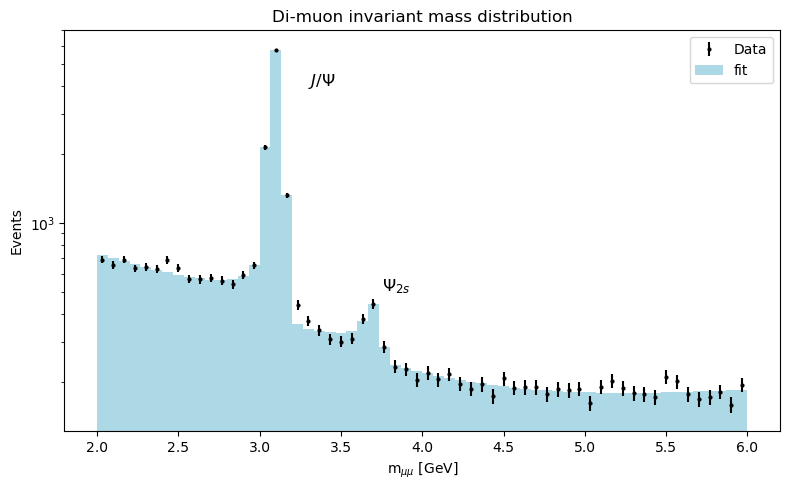

In [14]:
optimized_params = optimization_results.params
plot_fit(data, optimized_params, bin_number)

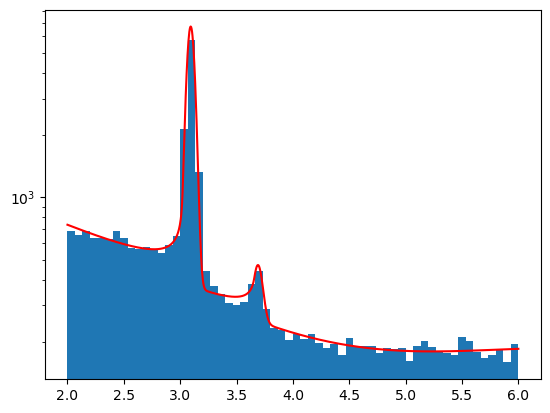

In [15]:
model = get_combined_model(optimized_params)
x = np.linspace(2,6,1000)
y = model(x)
plt.figure()
plt.hist(data, bins = bin_number, density = False)
plt.plot(x,y/15, "-r")
plt.yscale("log")
#the are between the two peaks is not well approximated by the model

In [16]:
'''data       = data_HS
bin_numbers = [30,40,50,55,60,65,70]
cross_sec = []
sigma_cross_sec = []
for Nbins in bin_numbers:

    bNLL = get_bNLL(data       = data,
                    bin_number = Nbins)
    optimization_results = lmfit.minimize(fcn    = bNLL,
                                          params = initial_params,
                                          method = 'lbfgsb')
    cross_sec.append(optimization_results.params['cross_section_Psi2S'].value)
    sigma_cross_sec.append(optimization_results.params['sigma_Psi2S'].value)'''

"data       = data_HS\nbin_numbers = [30,40,50,55,60,65,70]\ncross_sec = []\nsigma_cross_sec = []\nfor Nbins in bin_numbers:\n\n    bNLL = get_bNLL(data       = data,\n                    bin_number = Nbins)\n    optimization_results = lmfit.minimize(fcn    = bNLL,\n                                          params = initial_params,\n                                          method = 'lbfgsb')\n    cross_sec.append(optimization_results.params['cross_section_Psi2S'].value)\n    sigma_cross_sec.append(optimization_results.params['sigma_Psi2S'].value)"